In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("regression_salary_dataset.csv")
df.columns = df.columns.str.strip().str.lower()

In [3]:
X = df.drop("salary", axis=1)
y = df["salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [6]:
def evaluate(y_test, y_pred, name):
    print(name)
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2:", r2_score(y_test, y_pred))
    print()

In [7]:
evaluate(y_test, y_pred_lr, "Linear Regression")

Linear Regression
RMSE: 9921.853370165154
R2: 0.7869186049846828



In [ ]:
#Decision Tree

In [8]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [ ]:
#Random Forest

In [9]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
#XGBoost

In [10]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [ ]:
#Evaluate

In [11]:
evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_dt, "Decision Tree")
evaluate(y_test, y_pred_rf, "Random Forest")

# if xgboost works
evaluate(y_test, y_pred_xgb, "XGBoost")

Linear Regression
RMSE: 9921.853370165154
R2: 0.7869186049846828

Decision Tree
RMSE: 14916.827970701412
R2: 0.5183707162620735

Random Forest
RMSE: 10591.796485759947
R2: 0.7571717682883553

XGBoost
RMSE: 10724.661300013162
R2: 0.7510414123535156



In [ ]:
#Compare rwsults

In [12]:
results = {
    "Model": ["Linear", "Decision Tree", "Random Forest", "XGBoost"],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb) if 'y_pred_xgb' in locals() else None
    ]
}

results_df = pd.DataFrame(results)
print(results_df)

           Model  R2 Score
0         Linear  0.786919
1  Decision Tree  0.518371
2  Random Forest  0.757172
3        XGBoost  0.751041


In [ ]:
#Visualization

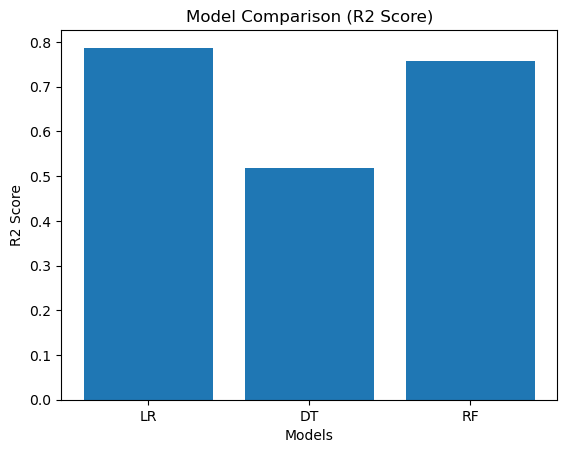

In [13]:
import matplotlib.pyplot as plt

models = ["LR", "DT", "RF"]
scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_dt),
    r2_score(y_test, y_pred_rf)
]

plt.bar(models, scores)
plt.title("Model Comparison (R2 Score)")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.show()

In [ ]:
Add

In [14]:
import pandas as pd

importance = rf.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feat_df)

           Feature  Importance
1       experience    0.682863
3   hours_per_week    0.124015
2  education_years    0.090204
0              age    0.065200
4      city_factor    0.037718


In [ ]:
#Result

           Model  R2 Score
0         Linear  0.786919
1  Decision Tree  0.518371
2  Random Forest  0.757172
3        XGBoost  0.751041
Linear Regression achieved the highest R² score, indicating that the relationship between features and salary is largely linear.
Random Forest and XGBoost performed slightly lower, suggesting that the dataset does not contain strong non-linear patterns.
Decision Tree showed poor performance due to overfitting.
Therefore, Linear Regression is the most suitable model